In [5]:
# Random Forest Classifier

# Importing the libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the datasets

datasets = pd.read_csv('Social_Network_Ads.csv')
X = datasets.iloc[:, [2,3]].values
Y = datasets.iloc[:, 4].values

In [6]:
print(datasets.columns[[2,3]])
print(datasets.columns[4])

Index(['Age', 'EstimatedSalary'], dtype='object')
Purchased


In [7]:
# Splitting the dataset into the Training set and Test set

from sklearn.model_selection import train_test_split
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

# Feature Scaling

from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_Train = sc_X.fit_transform(X_Train)
X_Test = sc_X.transform(X_Test)

In [8]:
# decision tree
# Create decision tree classifer object
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion="entropy",max_depth=None,
                                min_samples_split=5, min_samples_leaf=2)

model.fit(X_Train, Y_Train)  #training the model
print(model)

y_pred_dec = model.predict(X_Test)  # Predict the testing model
y_pred_dec

from sklearn.metrics import confusion_matrix # Making the Confusion Matrix
cm = confusion_matrix(Y_Test, y_pred_dec)
print(cm)

from sklearn.metrics import accuracy_score
print("Decision tree",accuracy_score(Y_Test,y_pred_dec))

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2,
                       min_samples_split=5)
[[63  5]
 [ 6 26]]
Decision tree 0.89


In [9]:
#Logistic Regression
# create an object of the algorithm / model
from sklearn.linear_model import LogisticRegression
modellr=LogisticRegression(random_state=0)

modellr.fit(X_Train, Y_Train)  #training the model
print(modellr)

y_pred_lr = modellr.predict(X_Test)  # Predict the testing model
y_pred_lr

from sklearn.metrics import confusion_matrix # Making the Confusion Matrix
cmlr = confusion_matrix(Y_Test, y_pred_lr)
print(cmlr)

from sklearn.metrics import accuracy_score
print("Logistic Regressin",accuracy_score(Y_Test,y_pred_lr))

LogisticRegression(random_state=0)
[[65  3]
 [ 8 24]]
Logistic Regressin 0.89


In [10]:
# Fitting the classifier into the Training set

from sklearn.ensemble import RandomForestClassifier
RFmodel= RandomForestClassifier(n_estimators = 200, criterion = 'entropy', random_state = 0)
RFmodel.fit(X_Train,Y_Train)

# Predicting the test set results

y_pred_rf = RFmodel.predict(X_Test)

from sklearn.metrics import confusion_matrix # Making the Confusion Matrix
cmrf = confusion_matrix(Y_Test, y_pred_rf)
print(cmrf)

from sklearn.metrics import accuracy_score
print("Random Forest",accuracy_score(Y_Test,y_pred_rf))

from sklearn.metrics import classification_report
print(classification_report(Y_Test,y_pred_rf))

[[64  4]
 [ 4 28]]
Random Forest 0.92
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        68
           1       0.88      0.88      0.88        32

    accuracy                           0.92       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.92      0.92      0.92       100



/tmp/ipykernel_1812/3841143094.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j, 1],


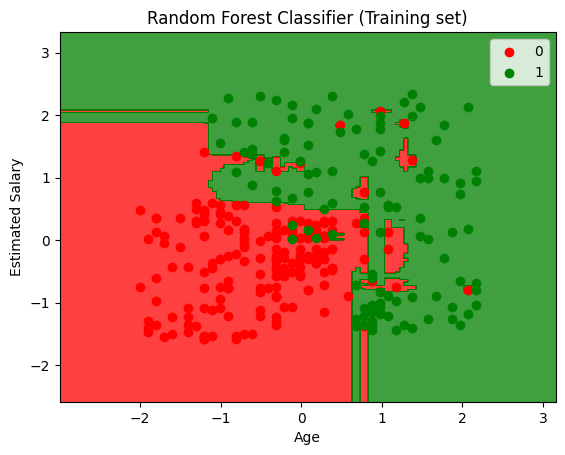

In [11]:
# Visualising the Training set results

from matplotlib.colors import ListedColormap
X_Set, Y_Set = X_Train, Y_Train
X1, X2 = np.meshgrid(np.arange(start = X_Set[:, 0].min() - 1, stop = X_Set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_Set[:, 1].min() - 1, stop = X_Set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, RFmodel.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Random Forest Classifier (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

/tmp/ipykernel_1812/2505670668.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j, 1],


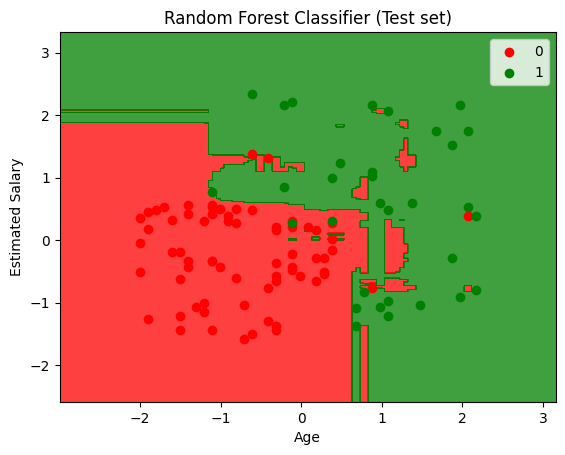

In [12]:
# Visualising the Test set results

from matplotlib.colors import ListedColormap
X_Set, Y_Set = X_Test, Y_Test
X1, X2 = np.meshgrid(np.arange(start = X_Set[:, 0].min() - 1, stop = X_Set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_Set[:, 1].min() - 1, stop = X_Set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, RFmodel.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Random Forest Classifier (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()


In [13]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_Train,Y_Train)
y_pred_nb = nb.predict(X_Test)
cmnb = confusion_matrix(Y_Test, y_pred_nb)
print(cmnb)
accuracy_nb = accuracy_score(Y_Test, y_pred_nb)
print("Accuracy:", accuracy_nb)


[[65  3]
 [ 7 25]]
Accuracy: 0.9


In [14]:
# Support Vector Machine (SVM)

from sklearn.svm import SVC

# Create SVM classifier object
#model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=0)
#model= SVC(kernel='linear')  #hyperparameter tuning
model=SVC(kernel='poly', degree=3)
#model=SVC(kernel='rbf')
# Training the model
model.fit(X_Train, Y_Train)
print(model)

# Predicting the test set results
y_pred_svm = model.predict(X_Test)
print(y_pred_svm)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_svc = confusion_matrix(Y_Test, y_pred_svm)
print(cm_svc)

# Accuracy
from sklearn.metrics import accuracy_score
print("SVM", accuracy_score(Y_Test, y_pred_svm))

SVC(kernel='poly')
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 0 0 1 0 1 1 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0]
[[67  1]
 [13 19]]
SVM 0.86


In [15]:
# Artificial Neural Network (ANN)

from sklearn.neural_network import MLPClassifier

# Create ANN model
model = MLPClassifier(hidden_layer_sizes=(6,6),
                      activation='relu',
                      solver='adam',
                      max_iter=1000,
                      random_state=0)

# Training the model
model.fit(X_Train, Y_Train)
print(model)

# Predicting the test set results
y_pred_ann = model.predict(X_Test)
print(y_pred_ann)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm_ann = confusion_matrix(Y_Test, y_pred_ann)
print(cm)

# Accuracy
from sklearn.metrics import accuracy_score
print("ANN", accuracy_score(Y_Test, y_pred_ann))

MLPClassifier(hidden_layer_sizes=(6, 6), max_iter=1000, random_state=0)
[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1]
[[63  5]
 [ 6 26]]
ANN 0.93
